# Runoff Forecasting Project - Group 9

**Members:** Alan Ray · Zach Shotwell · Miguel Moreno Coin  
**Course:** Artificial Intelligence, Appalachian State University  
**GitHub:** https://github.com/zachshotwell/AI-FinalProject-GroupSCR

**Dataset:** NOAA National Water Model (NWM) short-range streamflow forecasts paired with USGS observed streamflow for two stations from April 2021 through April 2023.  
**Task:** Predict forecast residual error, `USGS_obs - NWM_forecast`, for lead times 1–18 hours, then reconstruct corrected runoff forecasts — a multistep regression problem.  
**Approach:** After aligning NWM and USGS data on an hourly grid, we build per-station sequence datasets, compare recurrent neural-network post-processors against the raw NWM/persistence baseline, and evaluate corrected forecasts with per-lead-time hydrologic metrics.

## Setup

In [1]:
!git clone https://github.com/zachshotwell/AI-FinalProject-GroupSCR
%cd AI-FinalProject-GroupSCR
%cd RunoffForecastingProject
!ls

Cloning into 'AI-FinalProject-GroupSCR'...
remote: Enumerating objects: 2110, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 2110 (delta 22), reused 4 (delta 2), pack-reused 2071 (from 2)
Receiving objects: 100% (2110/2110), 59.16 MiB | 11.11 MiB/s, done.
Resolving deltas: 100% (1681/1681), done.
/content/AI-FinalProject-GroupSCR
/content/AI-FinalProject-GroupSCR/RunoffForecastingProject
 data
'Improved runoff forecasting performance through error predictions using a deep-learning approach.pdf'
 README.md
 RunoffForcastingProject.pdf
 RunoffForecasting.ipynb


In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

tf.keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

print('TF:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TF: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data Reconnaissance

Before building the loader, we inspect one USGS observation file and one monthly
NWM forecast file from each station folder to confirm the raw schema and time layout.

This check is used to verify:
- forecast layout (long vs. wide)
- column names and dtypes
- datetime fields and time coverage
- sampling cadence
- rough streamflow magnitude and likely units

This section is exploratory only; final cleaning, alignment, and unit handling are done in the loader section.

In [3]:
DATA_ROOT = Path("data")

# folder names are NWM reach IDs (NHDPlus COMIDs); paired USGS gauges:
stations = {
    "20380357": "09520500",
    "21609641": "11266500",
}

for nwm_id, usgs_id in stations.items():
    folder = DATA_ROOT / nwm_id
    print("\n" + "=" * 72)
    print(f"{folder}   (paired USGS gauge: {usgs_id})")
    print("=" * 72)

    csvs = sorted(folder.glob("*.csv"))
    usgs_file = next(f for f in csvs if "Strt" in f.name and "EndAt" in f.name)
    nwm_files = [f for f in csvs if f.name.startswith("streamflow_")]

    print(f"USGS file: {usgs_file.name}")
    print(f"NWM files: {len(nwm_files)}  (first: {nwm_files[0].name}, last: {nwm_files[-1].name})")

    print(f"\n--- USGS {usgs_id} ---")
    usgs_df = pd.read_csv(usgs_file)
    usgs_df.info()
    print(usgs_df.head(3))
    print("...")
    print(usgs_df.tail(3))

    print(f"\n--- NWM forecast (sample: {nwm_files[0].name}) ---")
    nwm_df = pd.read_csv(nwm_files[0])
    print(f"shape: {nwm_df.shape}  ->  {'LONG' if nwm_df.shape[1] <= 5 else 'WIDE'} format")
    print(nwm_df.head(3))

    # parse datetime columns to confirm coverage
    for col in [c for c in nwm_df.columns if "time" in c.lower()]:
        fmt = "%Y-%m-%d_%H:%M:%S" if "model_" in col else None
        t = pd.to_datetime(nwm_df[col], format=fmt, utc=True)
        print(f"  {col}: {t.min()} -> {t.max()}  ({t.nunique()} unique)")

    # quick unit check
    q_max = nwm_df["streamflow_value"].max()
    print(f"  streamflow_value max = {q_max:.2f}  ->  likely {'cfs' if q_max > 1000 else 'cms'}")


data/20380357   (paired USGS gauge: 09520500)
USGS file: 09520500_Strt_2021-04-20_EndAt_2023-04-21.csv
NWM files: 25  (first: streamflow_20380357_202104.csv, last: streamflow_20380357_202304.csv)

--- USGS 09520500 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70089 entries, 0 to 70088
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   DateTime       70089 non-null  object 
 1   USGSFlowValue  70089 non-null  float64
 2   USGS_GageID    70089 non-null  object 
dtypes: float64(1), object(2)
memory usage: 1.6+ MB
                    DateTime  USGSFlowValue USGS_GageID
0  2021-04-20 07:00:00+00:00           0.18           A
1  2021-04-20 07:15:00+00:00           0.18           A
2  2021-04-20 07:30:00+00:00           0.19           A
...
                        DateTime  USGSFlowValue USGS_GageID
70086  2023-04-22 06:15:00+00:00           0.15           A
70087  2023-04-22 06:30:00+00:00           0.15     

## Data Preparation

This section converts the raw NWM forecast files and USGS observations into a
single tidy hourly table for each station. The main steps are:
- parse NWM issue times and valid times
- resample USGS observations from 15-minute to hourly cadence
- align NWM forecasts with USGS observations on `valid_time`
- compute forecast residuals as `error = usgs_q - nwm_q`

The resulting tidy tables are saved for downstream splitting, windowing, model
training, and evaluation.

In [4]:
NWM_DT_FMT = "%Y-%m-%d_%H:%M:%S"  # underscore separator; explicit format avoids the slow dateutil fallback

def load_usgs_hourly(usgs_file):
    df = pd.read_csv(usgs_file)
    df["DateTime"] = pd.to_datetime(df["DateTime"], utc=True)
    s = df.set_index("DateTime")["USGSFlowValue"].sort_index()
    return s.asfreq("h").rename("usgs_q")  # instantaneous values, not aggregated

def load_nwm_station(folder):
    parts = []
    for f in sorted(folder.glob("streamflow_*.csv")):
        df = pd.read_csv(f)
        df["init_time"]  = pd.to_datetime(df["model_initialization_time"], format=NWM_DT_FMT, utc=True)
        df["valid_time"] = pd.to_datetime(df["model_output_valid_time"],   format=NWM_DT_FMT, utc=True)
        df["lead_h"] = ((df["valid_time"] - df["init_time"]).dt.total_seconds() // 3600).astype(int)
        df = df.rename(columns={"streamflow_value": "nwm_q"})
        parts.append(df[["init_time", "valid_time", "lead_h", "nwm_q"]])
    nwm = pd.concat(parts, ignore_index=True)
    return (nwm.drop_duplicates(["init_time", "lead_h"])
               .sort_values(["init_time", "lead_h"])
               .reset_index(drop=True))

for nwm_id, usgs_id in stations.items():
    folder = DATA_ROOT / nwm_id
    csvs = sorted(folder.glob("*.csv"))
    nwm_files = [f for f in csvs if f.name.startswith("streamflow_")]
    usgs_file = [f for f in csvs if f not in nwm_files][0]

    usgs = load_usgs_hourly(usgs_file)
    nwm = load_nwm_station(folder)

    df = nwm.merge(usgs, left_on="valid_time", right_index=True, how="left")
    df["error"] = df["usgs_q"] - df["nwm_q"]
    df = df[["valid_time", "init_time", "lead_h", "nwm_q", "usgs_q", "error"]]

    out = folder / f"tidy_{nwm_id}.parquet"
    df.to_parquet(out)

    print(f"\n=== Station {nwm_id} (USGS {usgs_id}) ===")
    print(f"rows: {len(df):,}   inits: {df['init_time'].nunique():,}   leads: {df['lead_h'].min()}..{df['lead_h'].max()}")
    print(f"valid_time: {df['valid_time'].min()} -> {df['valid_time'].max()}")
    print(f"missing usgs_q: {df['usgs_q'].isna().sum():,} ({df['usgs_q'].isna().mean():.1%})")

    lead1 = df[df["lead_h"] == 1].dropna()
    print(f"lead_h=1 (n={len(lead1):,}): nwm med={lead1['nwm_q'].median():.3f}  usgs med={lead1['usgs_q'].median():.3f}  error mean={lead1['error'].mean():+.3f}")
    print(f"wrote: {out}")


=== Station 20380357 (USGS 09520500) ===
rows: 315,789   inits: 17,544   leads: 1..18
valid_time: 2021-04-21 01:00:00+00:00 -> 2023-04-22 17:00:00+00:00
missing usgs_q: 1,164 (0.4%)
lead_h=1 (n=17,483): nwm med=3.930  usgs med=0.240  error mean=-4.840
wrote: data/20380357/tidy_20380357.parquet

=== Station 21609641 (USGS 11266500) ===
rows: 315,789   inits: 17,544   leads: 1..18
valid_time: 2021-04-21 01:00:00+00:00 -> 2023-04-22 17:00:00+00:00
missing usgs_q: 18,372 (5.8%)
lead_h=1 (n=16,527): nwm med=6.300  usgs med=7.080  error mean=+0.282
wrote: data/21609641/tidy_21609641.parquet


## Exploratory Data Analysis

This section visualizes the hourly lead-1 series for each station after alignment.
The goals are to:
- compare raw NWM forecasts against USGS observations
- inspect the residual series `error = usgs_q - nwm_q`
- summarize missing observations before imputation
- examine residual autocorrelation to assess whether a short input window such as `L = 6` is reasonable

Train, validation, and test periods are shaded to make the chronological split visible.

Missing-data summary (raw, before forward-fill):
  20380357: 61 / 17,544 hours missing USGS (0.3%)
  21609641: 1,017 / 17,544 hours missing USGS (5.8%)


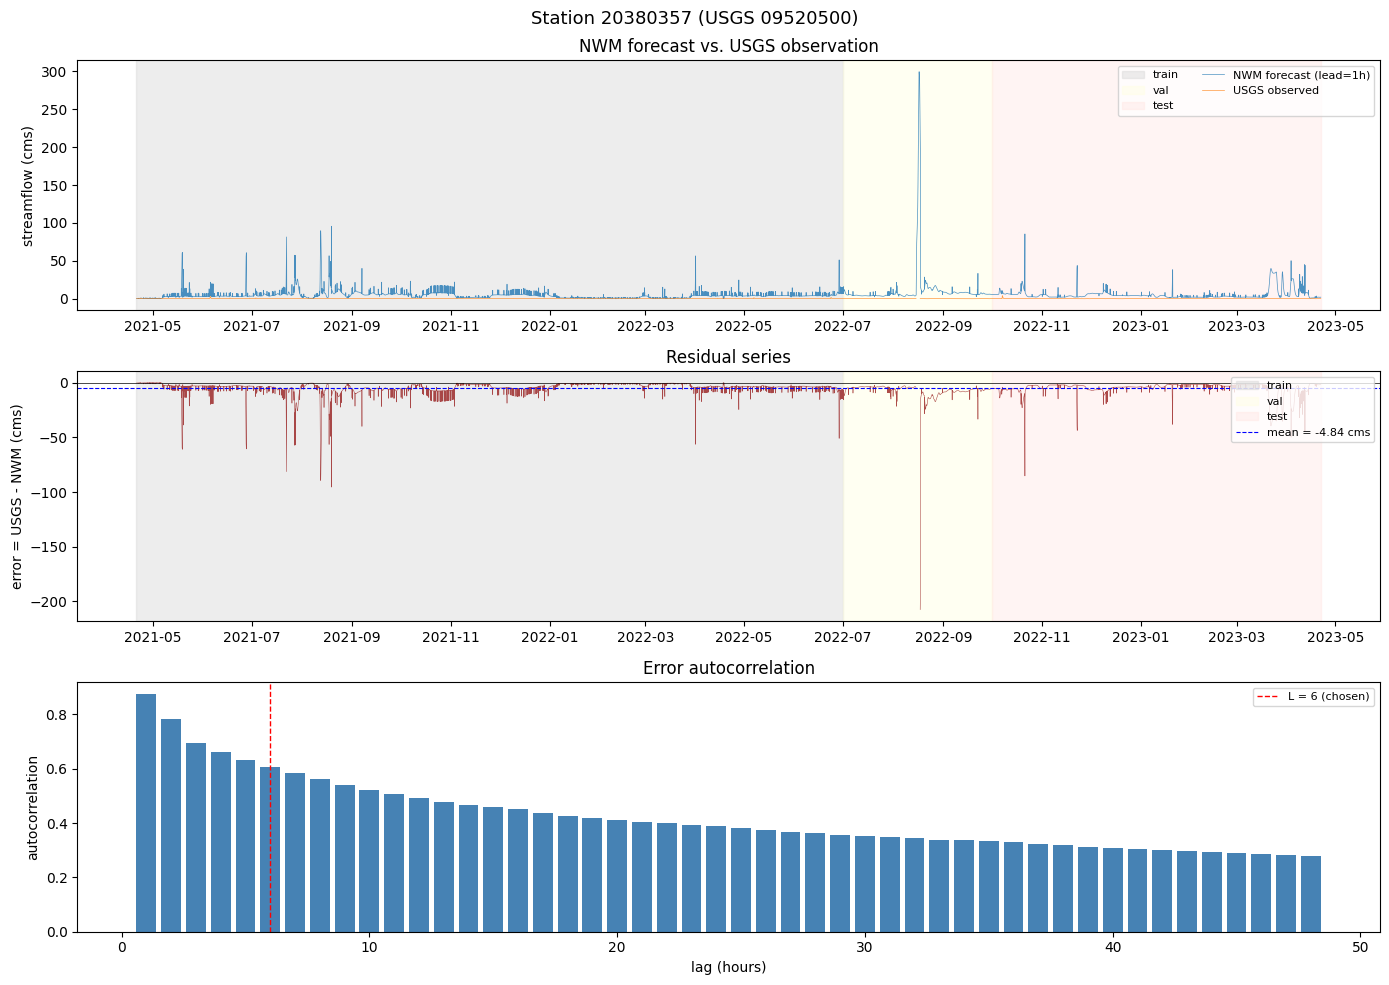

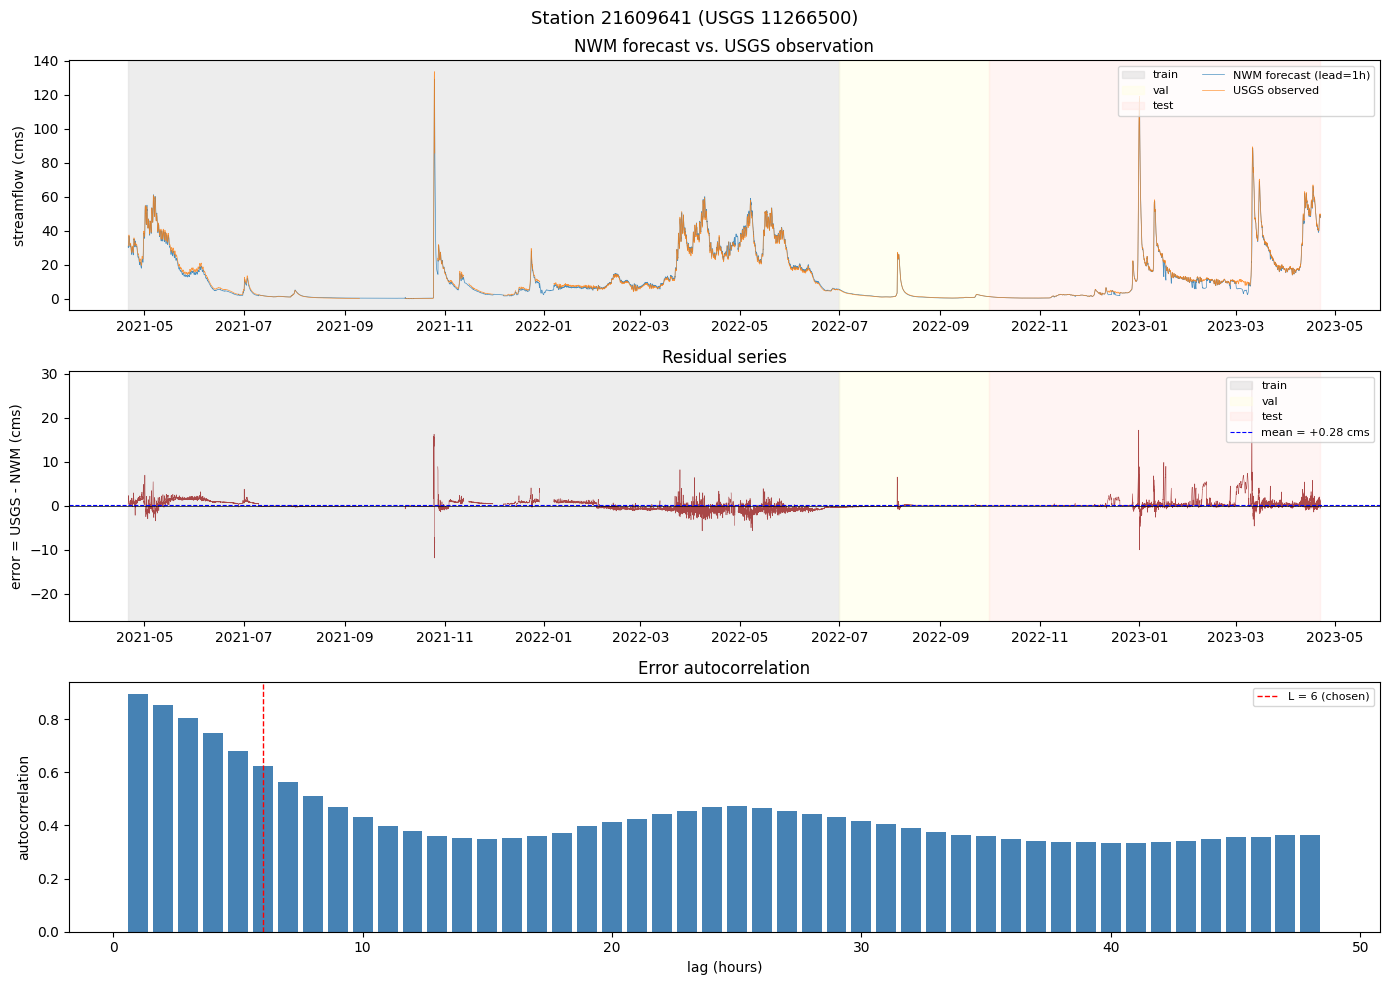

In [5]:
def load_tidy(station_id):
    df = pd.read_parquet(DATA_ROOT / station_id / f"tidy_{station_id}.parquet")
    df = df[df["lead_h"] == 1].set_index("valid_time").sort_index()
    return df[["nwm_q", "usgs_q", "error"]]

SPLITS = [
    ("2021-04-21", "2022-07-01", "lightgray",   "train"),
    ("2022-07-01", "2022-10-01", "lightyellow", "val"),
    ("2022-10-01", "2023-04-22", "mistyrose",   "test"),
]

def shade_splits(ax):
    for start, end, color, label in SPLITS:
        ax.axvspan(pd.Timestamp(start, tz="UTC"), pd.Timestamp(end, tz="UTC"),
                   alpha=0.4, color=color, label=label)

def plot_station(df, station_id, usgs_id):
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    fig.suptitle(f"Station {station_id} (USGS {usgs_id})", fontsize=13)

    ax = axes[0]
    shade_splits(ax)
    ax.plot(df.index, df["nwm_q"],  lw=0.5, alpha=0.8, label="NWM forecast (lead=1h)")
    ax.plot(df.index, df["usgs_q"], lw=0.5, alpha=0.8, label="USGS observed")
    ax.set_ylabel("streamflow (cms)")
    ax.set_title("NWM forecast vs. USGS observation")
    ax.legend(loc="upper right", fontsize=8, ncol=2)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

    ax = axes[1]
    shade_splits(ax)
    ax.plot(df.index, df["error"], lw=0.4, color="darkred", alpha=0.7)
    ax.axhline(0, color="black", lw=0.5)
    ax.axhline(df["error"].mean(), color="blue", lw=0.8, ls="--",
               label=f"mean = {df['error'].mean():+.2f} cms")
    ax.set_ylabel("error = USGS - NWM (cms)")
    ax.set_title("Residual series")
    ax.legend(loc="upper right", fontsize=8)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

    ax = axes[2]
    err = df["error"].dropna().values
    err = err - err.mean()
    var = (err ** 2).mean()
    lags = np.arange(1, 49)
    acf = np.array([(err[:-k] * err[k:]).mean() / var for k in lags])
    ax.bar(lags, acf, width=0.8, color="steelblue")
    ax.axhline(0, color="black", lw=0.5)
    ax.axvline(6, color="red", lw=1, ls="--", label="L = 6 (chosen)")
    ax.set_xlabel("lag (hours)")
    ax.set_ylabel("autocorrelation")
    ax.set_title("Error autocorrelation")
    ax.legend(loc="upper right", fontsize=8)

    plt.tight_layout()
    plt.show()

print("Missing-data summary (raw, before forward-fill):")
for sid in stations:
    df = load_tidy(sid)
    n, n_missing = len(df), df["usgs_q"].isna().sum()
    print(f"  {sid}: {n_missing:,} / {n:,} hours missing USGS ({n_missing/n:.1%})")

for sid, usgs_id in stations.items():
    plot_station(load_tidy(sid), sid, usgs_id)

## Chronological Train/Validation/Test Split

To prevent temporal leakage, each station’s tidy hourly table is split
chronologically using `valid_time` as the index.

Following the project specification:
- training and validation use April 2021 through September 2022
- testing uses October 2022 through April 2023

The validation set is taken from the most recent portion of the pre-test period,
which follows the common time-series convention of validating on the latest
available training-era data.

In [6]:
TRAIN_RANGE = ("2021-04", "2022-06")
VALID_RANGE = ("2022-07", "2022-09")
TEST_RANGE  = ("2022-10", "2023-04")

def split_station(sid):
    df = pd.read_parquet(DATA_ROOT / sid / f"tidy_{sid}.parquet")
    df = df.set_index("valid_time").sort_index()
    return (df.loc[TRAIN_RANGE[0]:TRAIN_RANGE[1]],
            df.loc[VALID_RANGE[0]:VALID_RANGE[1]],
            df.loc[TEST_RANGE[0]:TEST_RANGE[1]])

def report(name, df):
    n_days = df.index.normalize().nunique()
    print(f"  {name:6s}: {len(df):>7,} rows | {df.index.min()} -> {df.index.max()} | {n_days} unique days")

for sid in stations:
    print(f"\n{'='*70}\nstation {sid}\n{'='*70}")
    train, valid, test = split_station(sid)
    for name, part in [("train", train), ("valid", valid), ("test", test)]:
        report(name, part)
        part.reset_index().to_parquet(DATA_ROOT / sid / f"{name}_{sid}.parquet")
    print(f"  wrote: train_/valid_/test_{sid}.parquet")



station 20380357
  train : 188,181 rows | 2021-04-21 01:00:00+00:00 -> 2022-06-30 23:00:00+00:00 | 436 unique days
  valid :  39,744 rows | 2022-07-01 00:00:00+00:00 -> 2022-09-30 23:00:00+00:00 | 92 unique days
  test  :  87,864 rows | 2022-10-01 00:00:00+00:00 -> 2023-04-22 17:00:00+00:00 | 204 unique days
  wrote: train_/valid_/test_20380357.parquet

station 21609641
  train : 188,181 rows | 2021-04-21 01:00:00+00:00 -> 2022-06-30 23:00:00+00:00 | 436 unique days
  valid :  39,744 rows | 2022-07-01 00:00:00+00:00 -> 2022-09-30 23:00:00+00:00 | 92 unique days
  test  :  87,864 rows | 2022-10-01 00:00:00+00:00 -> 2023-04-22 17:00:00+00:00 | 204 unique days
  wrote: train_/valid_/test_21609641.parquet


## Sequencing Window and Dataset Construction

This section converts each station’s hourly time series into fixed-length input
and target sequences for recurrent neural network training.

The modeling setup is:
- input window length `L = 6` hours
- forecast horizon `H = 18` hours
- input features `[error, nwm_q, usgs_q]` at `lead_h = 1`
- target = the next 18 hourly residual values

Inputs are normalized using mean and standard deviation computed on the training
split only. Targets remain in raw `cms`, so predictions are directly interpretable
as forecast corrections in physical units.

In [7]:
L = 6
H = 18
BATCH_SIZE = 128

FEATURE_COLS = ["error", "nwm_q", "usgs_q"]
TARGET_COL = "error"


def prepare_features(split_df):
    # collapse to one row per hour at lead_h=1; forward/back-fill USGS gaps
    df = split_df[split_df["lead_h"] == 1].set_index("valid_time").sort_index()
    return df[FEATURE_COLS].ffill().bfill()


def build_seq2seq_targets(series, L, H):
    # row i  ==  series[i+L : i+L+H]
    N = len(series)
    n_windows = N - L - H + 1
    out = np.empty((n_windows, H), dtype=np.float32)
    for h in range(H):
        out[:, h] = series[L + h : N - H + 1 + h]
    return out


datasets = {sid: {} for sid in stations}
norm_stats = {}

for sid in stations:
    print(f"\n{'='*70}\nstation {sid}\n{'='*70}")

    splits = {name: pd.read_parquet(DATA_ROOT / sid / f"{name}_{sid}.parquet")
              for name in ("train", "valid", "test")}
    feats = {name: prepare_features(df) for name, df in splits.items()}

    mean = feats["train"].mean().values
    std = feats["train"].std().replace(0.0, 1.0).values
    norm_stats[sid] = (mean, std)

    for name, df in feats.items():
        x = ((df.values - mean) / std).astype(np.float32)
        # targets stay in raw cms so predictions are directly in physical units
        y_series = df[TARGET_COL].values.astype(np.float32)
        targets = build_seq2seq_targets(y_series, L, H)
        datasets[sid][name] = tf.keras.utils.timeseries_dataset_from_array(
            data=x[:-H],
            targets=targets,
            sequence_length=L,
            batch_size=BATCH_SIZE,
            shuffle=(name == "train"),
            seed=42,
        )

    print(f"  L={L}  H={H}  batch={BATCH_SIZE}")
    print(f"  features={FEATURE_COLS}   target={TARGET_COL} (raw cms)")
    print(f"  train norm stats:")
    for col, m, s in zip(FEATURE_COLS, mean, std):
        print(f"    {col:8s}  mean={m:8.3f}   std={s:8.3f}")
    print(f"  dataset shapes:")
    for name, ds in datasets[sid].items():
        x_batch, y_batch = next(iter(ds))
        n_batches = sum(1 for _ in ds)
        print(f"    {name:6s}  batches={n_batches:>4}   x={tuple(x_batch.shape)}   y={tuple(y_batch.shape)}")


station 20380357
  L=6  H=18  batch=128
  features=['error', 'nwm_q', 'usgs_q']   target=error (raw cms)
  train norm stats:
    error     mean=  -4.183   std=   5.547
    nwm_q     mean=   4.452   std=   5.545
    usgs_q    mean=   0.270   std=   0.132
  dataset shapes:
    train   batches=  82   x=(128, 6, 3)   y=(128, 18)
    valid   batches=  18   x=(128, 6, 3)   y=(128, 18)
    test    batches=  38   x=(128, 6, 3)   y=(128, 18)

station 21609641
  L=6  H=18  batch=128
  features=['error', 'nwm_q', 'usgs_q']   target=error (raw cms)
  train norm stats:
    error     mean=   0.212   std=   1.513
    nwm_q     mean=  13.158   std=  14.573
    usgs_q    mean=  13.374   std=  14.441
  dataset shapes:
    train   batches=  82   x=(128, 6, 3)   y=(128, 18)
    valid   batches=  18   x=(128, 6, 3)   y=(128, 18)
    test    batches=  38   x=(128, 6, 3)   y=(128, 18)


## Persistence Baseline

The persistence baseline uses the raw NWM forecast unchanged: predicted residual error is zero at every lead time. This is the "thing to beat" — any DL post-processor must outperform it to demonstrate value.

Predictions are saved with shape `(n_windows, H)`, matching the DL output format so all baselines can be evaluated through the same downstream pipeline.

In [8]:
for sid in stations:
    test_split = pd.read_parquet(DATA_ROOT / sid / f"test_{sid}.parquet")
    n_windows = len(prepare_features(test_split)) - L - H + 1
    preds = np.zeros((n_windows, H), dtype=np.float32)
    out = DATA_ROOT / sid / f"preds_persistence_{sid}.npy"
    np.save(out, preds)
    print(f"  {sid}: saved {out.name}  shape={preds.shape}")

  20380357: saved preds_persistence_20380357.npy  shape=(4850, 18)
  21609641: saved preds_persistence_21609641.npy  shape=(4850, 18)


## GRU and Stacked LSTM

Two recurrent architectures are trained per station, both predicting the 18-hour residual error sequence directly via a Dense head:

- **GRU**: `GRU(32) → Dense(18)` — NB2 model zoo entry 5.
- **Stacked LSTM**: `LSTM(32, return_sequences=True) → LSTM(32) → Dense(18)` — NB2 entry 3, with LSTM cells.

Both architectures use 32 recurrent units, following Han & Morrison's published sensitivity analysis. The architectures are deliberately shallow: with roughly 10,500 training windows, deeper networks tend to overfit.

Training configuration:

- Loss: Huber (robust to flood-peak outliers)
- Optimizer: Adam, learning rate `1e-3`, `clipnorm=1.0` (RNN BPTT exploding-gradient protection)
- Metric: MAE (in raw `cms`, since targets are unnormalized)
- Callbacks: `EarlyStopping(monitor="val_mae", patience=20, restore_best_weights=True)` and `ReduceLROnPlateau(factor=0.5, patience=5)`
- `clear_session()` and `set_seed(42)` before each model build, per Géron NB2 convention

For each `(station, model)` pair, the trained model and its test-set predictions are saved alongside the persistence baseline so all forecasts can be compared through a single downstream evaluation pipeline.

In [9]:
EPOCHS = 200
UNITS = 32  # paper's optimum for both architectures


def build_gru(n_features):
    tf.keras.backend.clear_session()
    tf.random.set_seed(42)
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(L, n_features)),
        tf.keras.layers.GRU(UNITS),
        tf.keras.layers.Dense(H),
    ])


def build_lstm_stacked(n_features):
    tf.keras.backend.clear_session()
    tf.random.set_seed(42)
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(L, n_features)),
        tf.keras.layers.LSTM(UNITS, return_sequences=True),
        tf.keras.layers.LSTM(UNITS),
        tf.keras.layers.Dense(H),
    ])


model_builders = {"gru": build_gru, "lstm_stacked": build_lstm_stacked}

gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs visible: {len(gpus)}")

n_features = len(FEATURE_COLS)
summary = {}

for sid in stations:
    print(f"\n{'='*70}\nstation {sid}\n{'='*70}")
    for model_name, build in model_builders.items():
        print(f"\n{'-'*70}\n  {sid}  /  {model_name}\n{'-'*70}")

        model = build(n_features)
        model.compile(
            loss=tf.keras.losses.Huber(),
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0),
            metrics=["mae"],
        )
        model.summary(line_length=70)

        callbacks = [
            tf.keras.callbacks.EarlyStopping(monitor="val_mae", patience=20, restore_best_weights=True),
            tf.keras.callbacks.ReduceLROnPlateau(monitor="val_mae", factor=0.5, patience=5),
        ]

        model.fit(
            datasets[sid]["train"],
            validation_data=datasets[sid]["valid"],
            epochs=EPOCHS,
            callbacks=callbacks,
            verbose=2,
        )

        _, val_mae = model.evaluate(datasets[sid]["valid"], verbose=0)
        _, test_mae = model.evaluate(datasets[sid]["test"], verbose=0)

        model.save(DATA_ROOT / sid / f"{model_name}_{sid}.keras")
        preds = model.predict(datasets[sid]["test"], verbose=0)
        np.save(DATA_ROOT / sid / f"preds_{model_name}_{sid}.npy", preds)

        summary[(sid, model_name)] = (val_mae, test_mae)
        print(f"  val_mae:  {val_mae:.4f} cms")
        print(f"  test_mae: {test_mae:.4f} cms")

print(f"\n{'='*70}\nfinal MAE summary (cms, lower=better)\n{'='*70}")
print(f"  {'station':<12} {'model':<14} {'val_mae':>10} {'test_mae':>10}")
for (sid, name), (vm, tm) in summary.items():
    print(f"  {sid:<12} {name:<14} {vm:>10.4f} {tm:>10.4f}")

GPUs visible: 1

station 20380357

----------------------------------------------------------------------
  20380357  /  gru
----------------------------------------------------------------------


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Layer (type)                 ┃ Output Shape          ┃     Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ gru (GRU)                    │ (None, 32)            │       3,552 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dense (Dense)                │ (None, 18)            │         594 │
└──────────────────────────────┴───────────────────────┴─────────────┘

 Total params: 4,146 (16.20 KB)

 Trainable params: 4,146 (16.20 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Layer (type)                 ┃ Output Shape          ┃     Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ lstm (LSTM)                  │ (None, 6, 32)         │       4,608 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ lstm_1 (LSTM)                │ (None, 32)            │       8,320 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dense (Dense)                │ (None, 18)            │         594 │
└──────────────────────────────┴───────────────────────┴─────────────┘

 Total params: 13,522 (52.82 KB)

 Trainable params: 13,522 (52.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
82/82 - 4s - 51ms/step - loss: 0.3707 - mae: 0.6588 - val_loss: 0.0229 - val_mae: 0.1159 - learning_rate: 0.0010
Epoch 2/200
82/82 - 2s - 29ms/step - loss: 0.2526 - mae: 0.4382 - val_loss: 0.0200 - val_mae: 0.0689 - learning_rate: 0.0010
Epoch 3/200
82/82 - 2s - 23ms/step - loss: 0.2340 - mae: 0.4101 - val_loss: 0.0200 - val_mae: 0.0616 - learning_rate: 0.0010
Epoch 4/200
82/82 - 2s - 22ms/step - loss: 0.2230 - mae: 0.3959 - val_loss: 0.0198 - val_mae: 0.0575 - learning_rate: 0.0010
Epoch 5/200
82/82 - 2s - 23ms/step - loss: 0.2161 - mae: 0.3858 - val_loss: 0.0190 - val_mae: 0.0527 - learning_rate: 0.0010
Epoch 6/200
82/82 - 2s - 23ms/step - loss: 0.2106 - mae: 0.3790 - val_loss: 0.0199 - val_mae: 0.0732 - learning_rate: 0.0010
Epoch 7/200
82/82 - 2s - 24ms/step - loss: 0.2059 - mae: 0.3755 - val_loss: 0.0198 - val_mae: 0.0776 - learning_rate: 0.0010
Epoch 8/200
82/82 - 3s - 32ms/step - loss: 0.2016 - mae: 0.3703 - val_loss: 0.0181 - val_mae: 0.0550 - learning_rate: 0.0010


## Hydrologic Evaluation

The corrected forecast for each model is reconstructed as `corrected = nwm_q + predicted_error`, since all DL models predict the residual rather than raw runoff. Four metrics are computed per lead time `h = 1..18`:

- **CC** — Pearson correlation
- **NSE** — Nash–Sutcliffe Efficiency
- **PBIAS** — percent bias (positive = overestimate)
- **RMSE** — in cms

Per station, the evaluation produces:

1. Per-lead-time line plots of all four metrics, comparing raw NWM, persistence, GRU, and stacked LSTM.
2. A scatter plot of corrected vs. observed at leads 1, 9, and 18 for the best-performing DL model (lowest mean RMSE across leads), with raw NWM points underneath for reference.
3. Two time-series snippets at `lead_h = 1` — one centered on the wettest observed hour, one on the driest — showing observed flow, raw NWM, and the best DL correction.

Persistence is included alongside raw NWM as a sanity check; the two should produce identical metrics, since persistence-of-zero-error is by definition the raw NWM forecast.


station 20380357


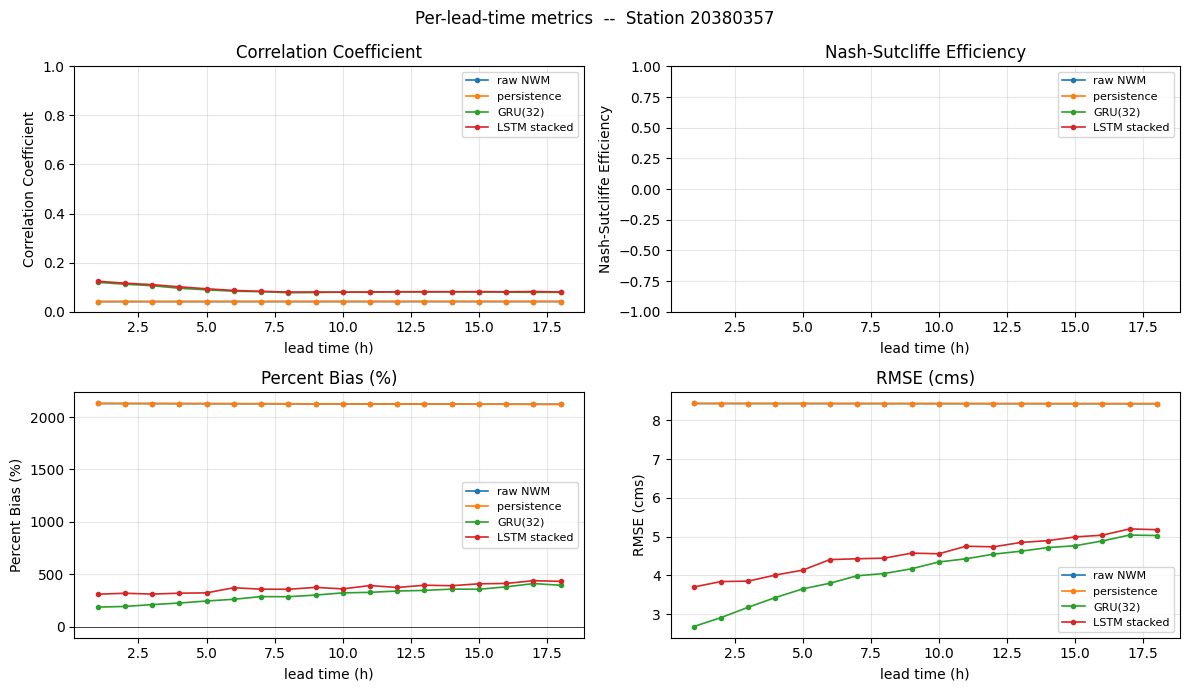

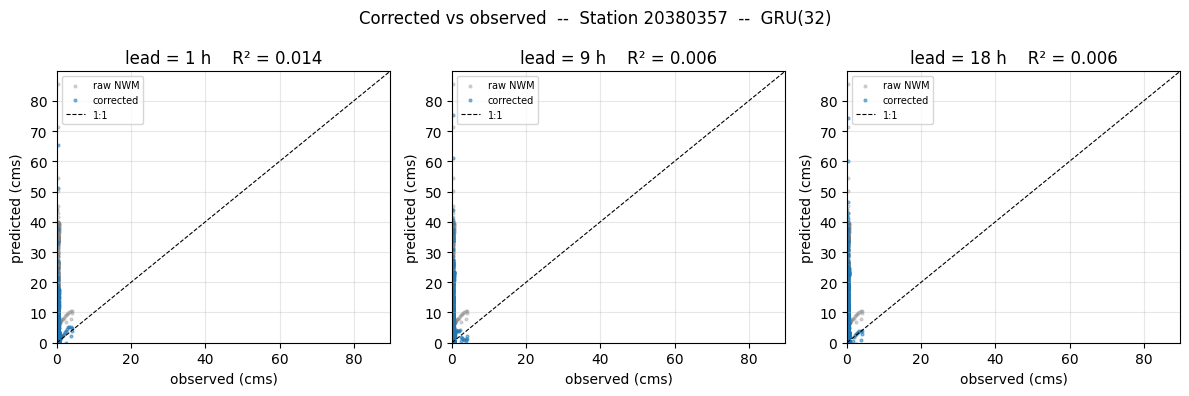

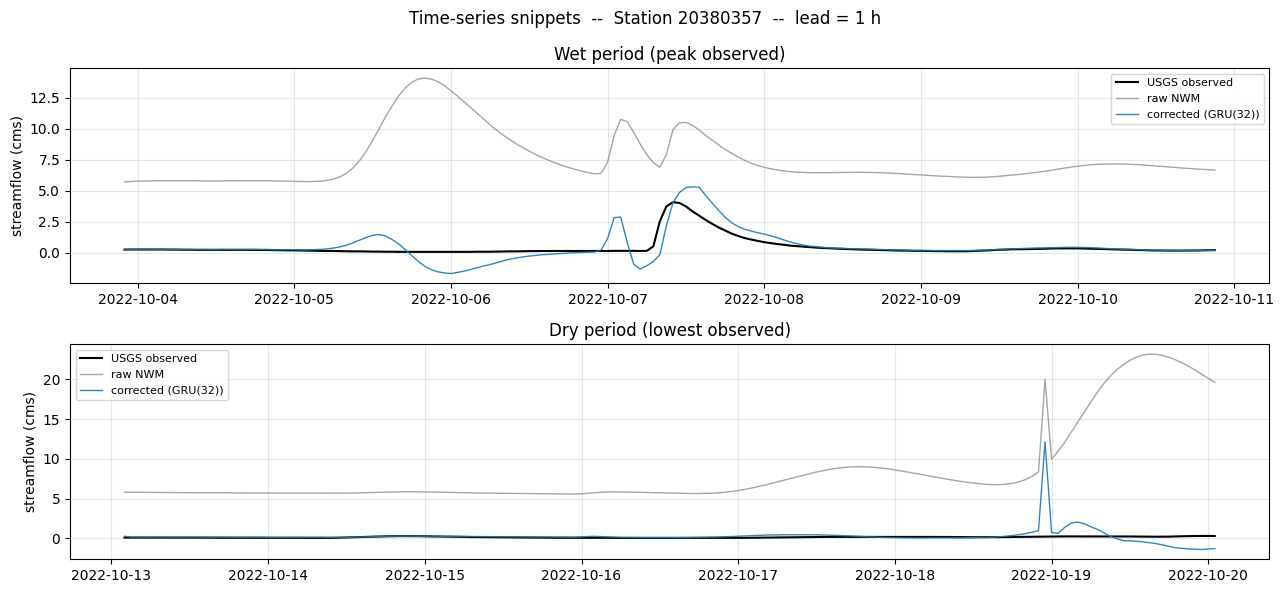


station 21609641


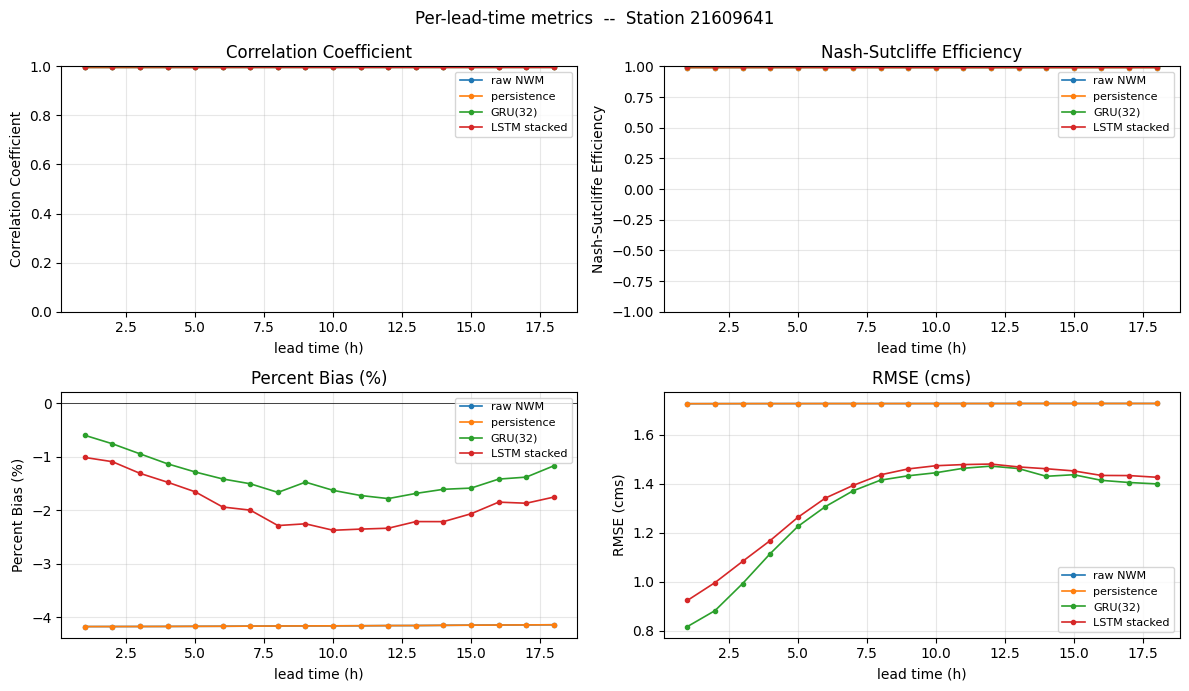

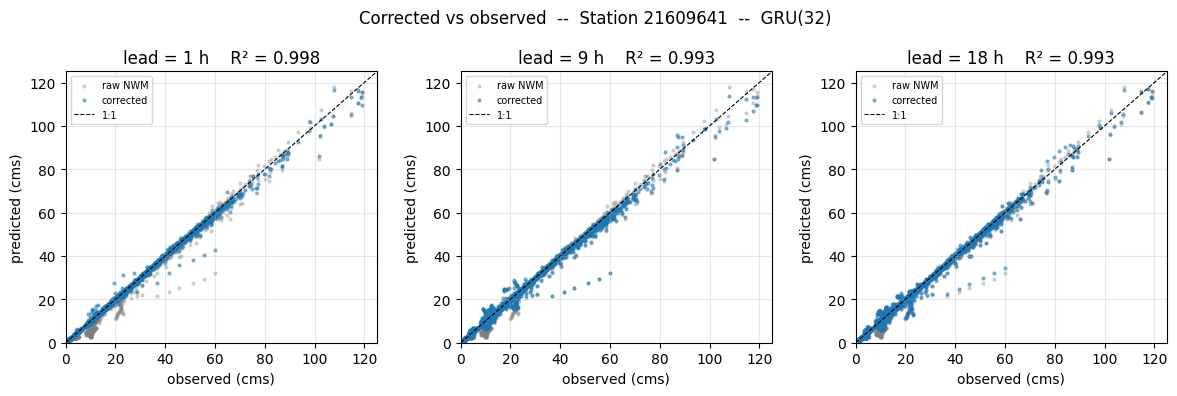

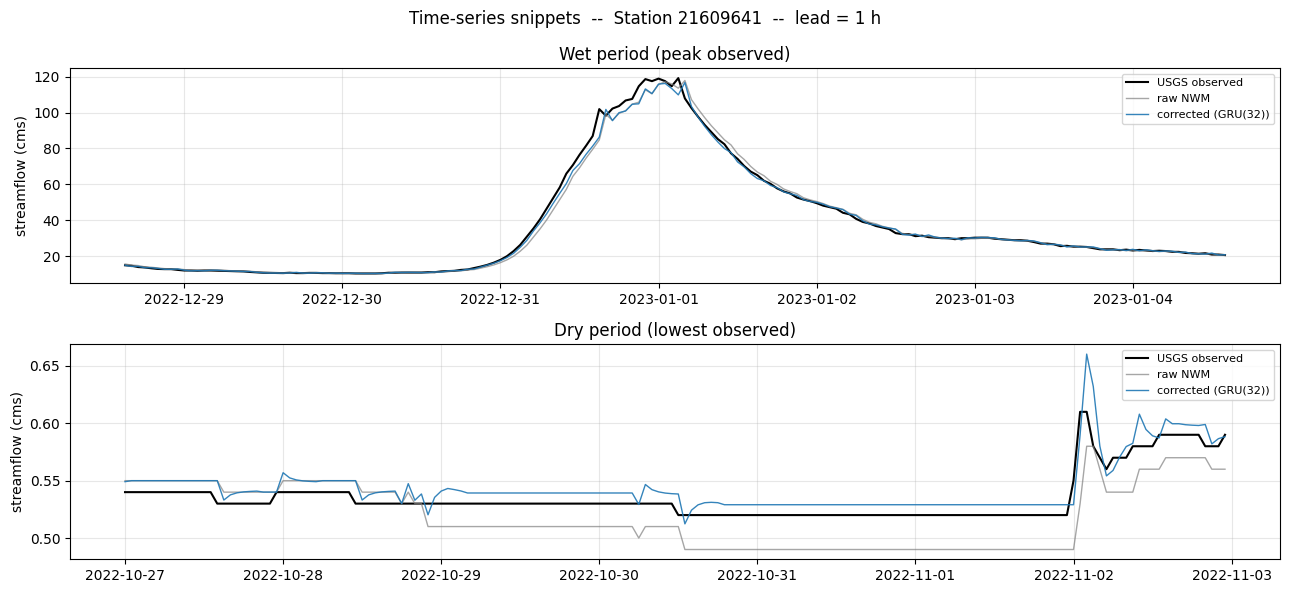


mean metrics across leads 1..18
                           cc          nse        pbias    rmse
station  model                                                 
20380357 gru           0.0869  -576.429016   301.053589  4.1261
         lstm_stacked  0.0893  -683.497192   368.531494  4.5340
         nwm_raw       0.0415 -2341.146973  2125.811279  8.4297
         persistence   0.0415 -2341.146973  2125.811279  8.4297
21609641 gru           0.9972     0.993800    -1.371200  1.3049
         lstm_stacked  0.9971     0.993500    -1.887000  1.3432
         nwm_raw       0.9953     0.989500    -4.155600  1.7276
         persistence   0.9953     0.989500    -4.155600  1.7276

  --- lead = 1 h ---
                           cc          nse        pbias    rmse
station  model                                                 
20380357 nwm_raw       0.0413 -2341.176758  2129.570312  8.4325
         persistence   0.0413 -2341.176758  2129.570312  8.4325
         gru           0.1197  -236.014694   185.

In [11]:
PRETTY = {
    "nwm_raw":      "raw NWM",
    "persistence":  "persistence",
    "gru":          "GRU(32)",
    "lstm_stacked": "LSTM stacked",
}


def cc(obs, sim):
    o, s = obs - obs.mean(), sim - sim.mean()
    denom = np.sqrt((o**2).sum() * (s**2).sum())
    return (o * s).sum() / denom if denom > 0 else np.nan


def nse(obs, sim):
    denom = ((obs - obs.mean()) ** 2).sum()
    return 1.0 - ((obs - sim) ** 2).sum() / denom if denom > 0 else np.nan


def pbias(obs, sim):
    s = obs.sum()
    return 100.0 * (sim - obs).sum() / s if s != 0 else np.nan


def rmse(obs, sim):
    return float(np.sqrt(((obs - sim) ** 2).mean()))


def evaluate_station(sid):
    print(f"\n{'='*70}\nstation {sid}\n{'='*70}")

    test_split = pd.read_parquet(DATA_ROOT / sid / f"test_{sid}.parquet")
    test_feats = prepare_features(test_split)
    nwm_grid = build_seq2seq_targets(test_feats["nwm_q"].values.astype(np.float32), L, H)
    obs_grid = build_seq2seq_targets(test_feats["usgs_q"].values.astype(np.float32), L, H)

    rows = []
    grids = {"nwm_raw": nwm_grid}

    for h in range(H):
        o, s = obs_grid[:, h], nwm_grid[:, h]
        rows.append({"station": sid, "model": "nwm_raw", "lead_h": h + 1,
                     "cc": cc(o, s), "nse": nse(o, s), "pbias": pbias(o, s), "rmse": rmse(o, s)})

    for name in ["persistence", "gru", "lstm_stacked"]:
        err_pred = np.load(DATA_ROOT / sid / f"preds_{name}_{sid}.npy")
        corrected = nwm_grid + err_pred
        grids[name] = corrected
        for h in range(H):
            o, s = obs_grid[:, h], corrected[:, h]
            rows.append({"station": sid, "model": name, "lead_h": h + 1,
                         "cc": cc(o, s), "nse": nse(o, s), "pbias": pbias(o, s), "rmse": rmse(o, s)})

    df = pd.DataFrame(rows)
    df.to_csv(DATA_ROOT / sid / f"metrics_{sid}.csv", index=False)
    return df, grids, obs_grid, test_feats


def plot_per_lead_metrics(df, sid):
    metrics = [("cc", "Correlation Coefficient", (0, 1)),
               ("nse", "Nash-Sutcliffe Efficiency", (-1, 1)),
               ("pbias", "Percent Bias (%)", None),
               ("rmse", "RMSE (cms)", None)]
    fig, axes = plt.subplots(2, 2, figsize=(12, 7))
    fig.suptitle(f"Per-lead-time metrics  --  Station {sid}", fontsize=12)

    for ax, (col, title, ylim) in zip(axes.flat, metrics):
        for model in df["model"].unique():
            sub = df[df["model"] == model]
            ax.plot(sub["lead_h"], sub[col], marker="o", ms=3, lw=1.2, label=PRETTY.get(model, model))
        if col == "pbias":
            ax.axhline(0, color="black", lw=0.5)
        ax.set_xlabel("lead time (h)")
        ax.set_ylabel(title)
        if ylim is not None:
            ax.set_ylim(*ylim)
        ax.set_title(title)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_scatter(grids, obs_grid, sid, best_name, leads=(1, 9, 18)):
    fig, axes = plt.subplots(1, len(leads), figsize=(4 * len(leads), 4))
    fig.suptitle(f"Corrected vs observed  --  Station {sid}  --  {PRETTY[best_name]}", fontsize=12)

    for ax, lead in zip(axes, leads):
        h = lead - 1
        o = obs_grid[:, h]
        nwm = grids["nwm_raw"][:, h]
        sim = grids[best_name][:, h]
        lim = max(o.max(), nwm.max(), sim.max()) * 1.05

        ax.scatter(o, nwm, s=4, alpha=0.3, color="gray", label="raw NWM")
        ax.scatter(o, sim, s=4, alpha=0.5, color="C0", label="corrected")
        ax.plot([0, lim], [0, lim], "k--", lw=0.8, label="1:1")
        ax.set_xlim(0, lim)
        ax.set_ylim(0, lim)
        ax.set_xlabel("observed (cms)")
        ax.set_ylabel("predicted (cms)")
        ax.set_title(f"lead = {lead} h    R² = {cc(o, sim)**2:.3f}")
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_timeseries_snippets(grids, obs_grid, test_feats, sid, best_name):
    n_windows = obs_grid.shape[0]
    valid_times = test_feats.index[L : L + n_windows]
    o_lead1 = obs_grid[:, 0]
    nwm_lead1 = grids["nwm_raw"][:, 0]
    sim_lead1 = grids[best_name][:, 0]

    span = 24 * 7
    wet_center = int(np.argmax(o_lead1))
    dry_center = int(np.argmin(o_lead1))

    fig, axes = plt.subplots(2, 1, figsize=(13, 6))
    fig.suptitle(f"Time-series snippets  --  Station {sid}  --  lead = 1 h", fontsize=12)

    for ax, center, label in [(axes[0], wet_center, "Wet period (peak observed)"),
                              (axes[1], dry_center, "Dry period (lowest observed)")]:
        lo = max(0, center - span // 2)
        hi = min(n_windows, center + span // 2)
        idx = slice(lo, hi)
        ax.plot(valid_times[idx], o_lead1[idx], "k", lw=1.5, label="USGS observed")
        ax.plot(valid_times[idx], nwm_lead1[idx], color="gray", lw=1, alpha=0.7, label="raw NWM")
        ax.plot(valid_times[idx], sim_lead1[idx], color="C0", lw=1, alpha=0.9,
                label=f"corrected ({PRETTY[best_name]})")
        ax.set_ylabel("streamflow (cms)")
        ax.set_title(label)
        ax.legend(fontsize=8)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


parts = []
for sid in stations:
    df_s, grids, obs_grid, test_feats = evaluate_station(sid)
    parts.append(df_s)

    # best DL model = lowest mean RMSE across leads
    best = min(
        ["gru", "lstm_stacked"],
        key=lambda n: np.mean([rmse(obs_grid[:, h], grids[n][:, h]) for h in range(H)]),
    )

    plot_per_lead_metrics(df_s, sid)
    plot_scatter(grids, obs_grid, sid, best)
    plot_timeseries_snippets(grids, obs_grid, test_feats, sid, best)

df_all = pd.concat(parts, ignore_index=True)

print(f"\n{'='*70}\nmean metrics across leads 1..18\n{'='*70}")
print(df_all.groupby(["station", "model"])[["cc", "nse", "pbias", "rmse"]].mean().round(4).to_string())

for lead in (1, 18):
    print(f"\n  --- lead = {lead} h ---")
    print(df_all[df_all["lead_h"] == lead]
          .set_index(["station", "model"])[["cc", "nse", "pbias", "rmse"]]
          .round(4).to_string())